<a href="https://colab.research.google.com/github/dherreraal/data_structures/blob/main/Clase_02/02_Arrays_LinkedLists.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estructuras de Datos Secuenciales: Arreglos y Listas Enlazadas
### Universidad Nacional de Colombia
#### **Profesor:** David Alberto Herrera Alvarez
#### **Curso:** Estructuras de Datos
---


## Índice de Contenido
1. Estructuras de Datos Secuenciales: Arreglos (Arrays)
2. Aritmética de Memoria en Arreglos
3. Arreglos Multidimensionales (Row-Major vs Column-Major)
4. Complejidad de Operaciones en Arreglos (Push/Pop)
5. Laboratorio 1: Arreglos en la Práctica (Java)
6. Listas Enlazadas (Singly-Linked Lists)
7. La API de las Listas Enlazadas (List API)
8. Complejidad en Listas Enlazadas
9. Laboratorio 2: Implementando nuestra primera Lista Enlazada
10. Bibliografía y Referencias
---


## 1. Estructuras de Datos Secuenciales: Arreglos (Arrays)

Para entender las Estructuras de Datos, debemos hablar de la más fundamental de todas: **El Arreglo (Array)**.

### Definición Formal
Un Arreglo es un área **contigua** de memoria que consiste en elementos del **mismo tamaño**, los cuales son indexados por enteros secuenciales.

La palabra clave aquí es *contigua*. Cuando usted declara `int[] datos = new int[5];`, el sistema operativo busca un bloque ininterrumpido en la memoria RAM que sea lo suficientemente grande para albergar 5 números enteros juntos.

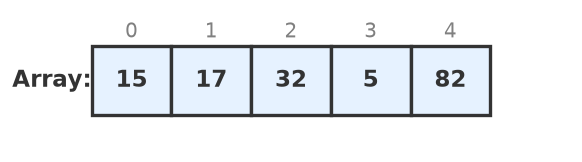

El hecho de que estén uno al lado del otro es la mayor ventaja del arreglo, y a la vez, su peor debilidad.


---
## 2. Aritmética de Memoria en Arreglos

¿Por qué acceder a `datos[4]` es tan extremadamente rápido (complejidad **$O(1)$**)?

A diferencia de los humanos, que tendríamos que contar desde la posición 0 hasta la 4, la computadora no cuenta; **calcula matemáticamente** la dirección de memoria exacta donde se encuentra el dato usando la siguiente fórmula:

> `Dirección = direccion_base + tamaño_elemento * (índice - primer_índice)`

Por ejemplo, si un entero (`int`) ocupa 4 bytes en memoria, y nuestro arreglo comienza en la dirección de memoria `1000`:
*   Para ir a `datos[0]`: `1000 + 4 * (0 - 0) = 1000`
*   Para ir a `datos[3]`: `1000 + 4 * (3 - 0) = 1012`

Esta simple multiplicación suma de la CPU es todo lo que toma encontrar el dato. Por eso el **Acceso Aleatorio (Random Access)** en arreglos toma tiempo **$O(1)$**.


---
## 3. Arreglos Multidimensionales (Row-Major vs Column-Major)

A nivel de hardware, la memoria RAM es un vector gigante unidimensional. No existen las matrices 2D o 3D físicamente. Cuando declaramos una matriz en Java `int[][] matriz`, el compilador debe "aplastarla" (linearizarla) para guardarla en memoria.

Existen dos estrategias principales para esto:

### 1. Row-major order (Orden por filas)
Se guarda la fila 1 completa, seguida inmediatamente por la fila 2 completa. (Es el estándar en lenguajes como C, C++ y Python).

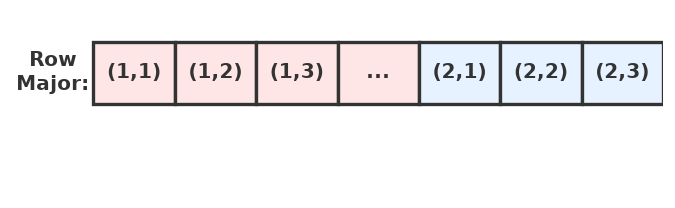

### 2. Column-major order (Orden por columnas)
Se guarda la columna 1 completa, seguida por la columna 2. (Es el estándar en Fortran o Matlab).

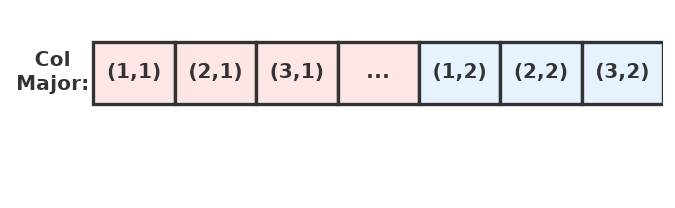

Conocer cómo su lenguaje de programación guarda las matrices es vital para la optimización de caché, pero matemáticamente, ambas siguen garantizando un tiempo de acceso **$O(1)$** porque existe una fórmula fija para saltar a cualquier fila y columna.


---
## 4. Complejidad de Operaciones en Arreglos (Push/Pop)

Supongamos que nuestro arreglo tiene capacidad, pero necesitamos insertar (`Push`) o remover (`Pop`) un elemento.

### 1. Operar al final (End)
Añadir un nuevo elemento al final de los datos existentes toma tiempo **$O(1)$**, porque simplemente escribimos en el siguiente bloque vacío de la memoria.
Remover al final también es **$O(1)$**.

### 2. Operar al inicio (Beginning) o al medio (Middle)
Si usted tiene los números `[5, 8, 3]` y quiere hacer un `PushFront(4)` para que quede `[4, 5, 8, 3]`, hay un problema gravísimo: ¡El `5` ya ocupa el primer puesto!

Para solucionar esto, la computadora se ve obligada a mover el `3` a la derecha, luego el `8` a la derecha, y luego el `5` a la derecha, creando el hueco para meter el `4`.

Desplazar todos los elementos demanda tiempo **$O(n)$**.

**Tabla Resumen de Complejidad en Arreglos:**

| Operación | Complejidad |
| :--- | :---: |
| Lectura / Acceso Indexado | $O(1)$ |
| Agregar al final (PushBack) | $O(1)$ |
| Remover al final (PopBack) | $O(1)$ |
| Agregar al inicio/medio (PushFront) | **$O(n)$** |
| Remover al inicio/medio (PopFront) | **$O(n)$** |


---
## 5. Laboratorio 1: Arreglos en la Práctica (Java)

Vamos a comprobar empíricamente por qué la teoría asintótica no miente. Vamos a crear un programa en Java que realiza dos pruebas sobre un arreglo estático parcialmente lleno:
1. Insertar un elemento al final.
2. Insertar un elemento al inicio (moviendo todos manualmente).

In [1]:
%%writefile PruebaArreglos.java
public class PruebaArreglos {

    // O(1) - Push Back
    public static void pushBack(int[] arr, int size, int value) {
        arr[size] = value; // Se escribe directamente en el hueco final
    }

    // O(n) - Push Front
    public static void pushFront(int[] arr, int size, int value) {
        // Recorremos de atras hacia adelante moviendo todo una posicion
        for(int i = size; i > 0; i--) {
            arr[i] = arr[i-1];
        }
        arr[0] = value; // Insertamos en la nueva casilla disponible
    }

    public static void main(String[] args) {
        int capacidad = 10;
        int[] arr = new int[capacidad];
        int size = 0;

        // Llenamos con 3 elementos
        pushBack(arr, size++, 10);
        pushBack(arr, size++, 20);
        pushBack(arr, size++, 30);

        System.out.print("Estado inicial (PushBack O(1)): ");
        for(int i=0; i<size; i++) System.out.print(arr[i] + " ");
        System.out.println();

        // Ahora insertamos al inicio
        pushFront(arr, size++, 99);

        System.out.print("Despues del PushFront O(n)  : ");
        for(int i=0; i<size; i++) System.out.print(arr[i] + " ");
        System.out.println();
    }
}


Writing PruebaArreglos.java


In [2]:
!javac PruebaArreglos.java
!java PruebaArreglos

[0.031s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.031s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Estado inicial (PushBack O(1)): 10 20 30 
Despues del PushFront O(n)  : 99 10 20 30 


---
## 6. Listas Enlazadas (Singly-Linked Lists)

Como acabamos de comprobar, los arreglos son inflexibles. Tienen tamaño estático y modificarlos por el frente es increíblemente lento $O(n)$.

Aquí es donde nacen las **Listas Enlazadas**. A diferencia del arreglo, una lista enlazada *no* guarda la memoria de manera contigua. Utiliza objetos dinámicos aislados esparcidos por la memoria RAM llamados **Nodos**.

Para que la lista no se pierda, cada Nodo contiene dos partes:
1.  **La llave o valor (Key/Value)**: La información real a guardar.
2.  **El Puntero (Next Pointer)**: La dirección de memoria donde se esconde el *siguiente* Nodo.

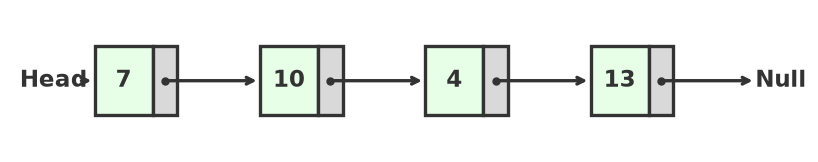

Al nodo principal desde donde empieza el encadenamiento se le denomina **Head** (Cabeza). Al último elemento, si llevamos registro de él para mayor eficiencia, se le conoce como **Tail** (Cola).

---
## 7. La API de las Listas Enlazadas (List API)

La interfaz oficial (el Abstract Data Type o ADT) de una lista clásica requiere implementar un set estandarizado de operaciones lógicas.

Esta es la API fundamental:
*   `PushFront(Key)`: Agrega un elemento al inicio.
*   `Key TopFront()`: Retorna el elemento en la cabeza.
*   `PopFront()`: Remueve el primer elemento.
*   `PushBack(Key)`: Agrega al final (Append).
*   `Key TopBack()`: Retorna el último elemento.
*   `PopBack()`: Remueve el último elemento.
*   `Boolean Find(Key)`: Verifica si una llave existe.
*   `Erase(Key)`: Busca y elimina una llave específica.
*   `Boolean Empty()`: Verifica si la lista está vacía.
*   `AddBefore(Node, Key)`: Inserta justo antes de un nodo en específico.
*   `AddAfter(Node, Key)`: Inserta inmediatamente después.

---
## 8. Complejidad en Listas Enlazadas

Las listas enlazadas voltean las debilidades del arreglo, convirtiéndolas en fortalezas. Sin embargo, pierden el acceso instantáneo.

| Operación | Complejidad Singly-Linked |
| :--- | :---: |
| PushFront / PopFront | **$O(1)$** 🔥 (¡Excelente!) |
| PushBack | **$O(1)$** (Si mantenemos un puntero `Tail`) |
| PopBack | **$O(n)$** (No podemos ir marcha atrás sin un puntero `prev`) |
| Búsqueda (Find / Access) | **$O(n)$** ⚠️ (Hay que recorrerla nodo a nodo) |

¿Nota el contraste? Para agregar clientes VIP rápidos al frente de una fila, las listas enlazadas son invencibles $O(1)$, mientras que el arreglo colapsaba iterando $O(n)$.

---
## 9. Laboratorio 2: Implementando nuestra primera Lista Enlazada

Llegó el momento de codificar todo lo aprendido. Vamos a crear la abstracción estructural en Java: Una clase `Node` para alojar los datos, y una clase `SinglyLinkedList` que gestionará la `Head` y ejecutará la operación estrella: **PushFront** en tiempo $O(1)$.

In [3]:
%%writefile SinglyLinkedList.java
// 1. La clase Nodo (Estructura interna)
class Node {
    int key;
    Node next;

    public Node(int key) {
        this.key = key;
        this.next = null;
    }
}

// 2. La clase Lista Enlazada (ADT)
public class SinglyLinkedList {
    private Node head;

    public SinglyLinkedList() {
        this.head = null;
    }

    // Operacion PushFront: Complejidad O(1) - Magia sin mover datos
    public void pushFront(int key) {
        Node newNode = new Node(key);
        // El nuevo nodo apunta a la antigua cabeza
        newNode.next = head;
        // Ahora el nuevo nodo toma el trono de la cabeza
        head = newNode;
    }

    // Operacion de Recorrido O(n)
    public void printList() {
        Node current = head;
        System.out.print("Head -> ");
        while (current != null) {
            System.out.print(current.key + " -> ");
            current = current.next;
        }
        System.out.println("Null");
    }

    public static void main(String[] args) {
        SinglyLinkedList list = new SinglyLinkedList();

        list.pushFront(13);
        list.pushFront(4);
        list.pushFront(10);
        list.pushFront(7);

        System.out.println("=== Estado de la Lista Enlazada ===");
        list.printList();
    }
}


Writing SinglyLinkedList.java


In [4]:
!javac SinglyLinkedList.java
!java SinglyLinkedList

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
=== Estado de la Lista Enlazada ===
Head -> 7 -> 10 -> 4 -> 13 -> Null


Observe bien lo que sucedió en `pushFront`. Nunca necesitamos usar un bucle `for` para mover los elementos antiguos (el 10, el 4, el 13). Simplemente hicimos que el nuevo puntero *apuntara* al primer bloque viejo, resolviendo todo en 2 pasos de asignación en memoria ($O(1)$).

---
## 10. Bibliografía y Referencias
*   Streib, J. T., & Soma, T. (2017). *Guide to Data Structures: A Concise Introduction Using Java*.
    *   *Chapter 4: Lists Using Arrays*.
    *   *Chapter 6: Linked Lists*.
*   Rhodes, Neil (UCSD). *Basic Data Structures: Arrays and Linked Lists* (Diapositivas de Curso).
